In [1]:
import uproot

In [2]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
#Main program 
chamber = "ME12HV1"
year = "2017"


input_dir   = f"/eos/home-n/nrawal/CSCAgeing/Run2_Ntuples/{year}_updated/"
filename  = f"{input_dir}csc_output_{year}_{chamber}_tree_updated.root"
treename = "tree"   # change this


In [24]:
#Opening root file and returning dataframe
# Mention all dataframes you want to read
def opening_file_dataframe(filename, treename):
    with uproot.open(filename) as f:
        print(f.keys())
        tree = f[treename]
        arr = tree.arrays(["_rhsumQ_RAW", "_rhsumQ_equalised_HV_data", "_runNb",
                           "_rhid",  "_n_PV", "_instlumi_dcsjson"], library="pd")
    df = arr
    return df

In [25]:
#Make dataframe
df = opening_file_dataframe(filename, treename)


['tree;17']


In [26]:
df

,_rhsumQ_RAW,_rhsumQ_equalised_HV_data,_runNb,_rhid,_n_PV,_instlumi_dcsjson
0,1023.554810,1212.439779,297219,1122011,19,7403.412670
1,1283.874756,1054.656012,297219,1122021,19,7403.412670
2,3445.586914,2709.386585,297219,1122031,19,7403.412670
3,572.570862,480.737077,297219,1122041,19,7403.412670
4,375.515900,320.497287,297219,1122051,19,7403.412670
...,...,...,...,...,...,...
12707869,614.494751,518.763133,305046,2121321,11,5919.808613
12707870,307.351105,300.707718,305046,2121331,11,5919.808613
12707871,411.591675,338.107461,305046,2121341,11,5919.808613
12707872,315.504578,279.775415,305046,2121351,11,5919.808613


In [27]:
bx_df = pd.read_csv("Bunch_crossing_2017.csv")

# Split "275809 - 275848" into run_min and run_max
runs = bx_df["Run"].astype(str).str.split("-", expand=True)

bx_df["run_min"] = runs[0].str.strip().astype(int)
bx_df["run_max"] = runs[1].str.strip().astype(int)
bx_df["Bx"] = bx_df["Bx"].astype(int)

print(bx_df.head())

   Fill              Run    Bx  Unnamed: 3  run_min  run_max
0  6364  306151 - 306171  1866         NaN   306151   306171
1  6360  306112 - 306126  1866         NaN   306112   306126
2  6362  306132 - 306139  1866         NaN   306132   306139
3  6371  306438 - 306462  1866         NaN   306438   306462
4  6291  304791 - 304797  1866         NaN   304791   304797


In [28]:
intervals = pd.IntervalIndex.from_arrays(
    bx_df["run_min"],
    bx_df["run_max"],
    closed="both"
)

idx = intervals.get_indexer(df["_runNb"])

df["nBX"] = np.where(
    idx >= 0,
    bx_df.iloc[idx]["Bx"].to_numpy(),
    np.nan
)

print(df[["_runNb", "nBX"]].head())
print("Runs without nBX match:", df["nBX"].isna().sum())

   _runNb     nBX
0  297219  2017.0
1  297219  2017.0
2  297219  2017.0
3  297219  2017.0
4  297219  2017.0
Runs without nBX match: 0


In [29]:
plot_df = df.dropna(
    subset=["nBX", "_n_PV", "_instlumi_dcsjson"]
).copy()

plot_df = plot_df[plot_df["_instlumi_dcsjson"] > 0]

In [30]:
plot_df

,_rhsumQ_RAW,_rhsumQ_equalised_HV_data,_runNb,_rhid,_n_PV,_instlumi_dcsjson,nBX
0,1023.554810,1212.439779,297219,1122011,19,7403.412670,2017.0
1,1283.874756,1054.656012,297219,1122021,19,7403.412670,2017.0
2,3445.586914,2709.386585,297219,1122031,19,7403.412670,2017.0
3,572.570862,480.737077,297219,1122041,19,7403.412670,2017.0
4,375.515900,320.497287,297219,1122051,19,7403.412670,2017.0
...,...,...,...,...,...,...,...
12707869,614.494751,518.763133,305046,2121321,11,5919.808613,1866.0
12707870,307.351105,300.707718,305046,2121331,11,5919.808613,1866.0
12707871,411.591675,338.107461,305046,2121341,11,5919.808613,1866.0
12707872,315.504578,279.775415,305046,2121351,11,5919.808613,1866.0


In [31]:
run_df = (
    plot_df.groupby("_runNb")
    .agg(
        nBX=("nBX", "first"),
        mean_PV=("_n_PV", "mean"),
        mean_instLumi=("_instlumi_dcsjson", "mean"),
        n_events=("_runNb", "size")
    )
    .reset_index()
)

run_df["PV_over_instLumi"] = run_df["mean_PV"] / run_df["mean_instLumi"]

print(run_df.head())

   _runNb     nBX    mean_PV  mean_instLumi  n_events  PV_over_instLumi
0  297050  1213.0  27.618206    5981.998106     26716          0.004617
1  297056  1213.0  33.113074    7430.290548      8888          0.004456
2  297057  1213.0  27.659683    6004.194219     32649          0.004607
3  297099  1549.0  36.433370    9927.353903      1816          0.003670
4  297100  1549.0  32.062644    8960.195210     20832          0.003578


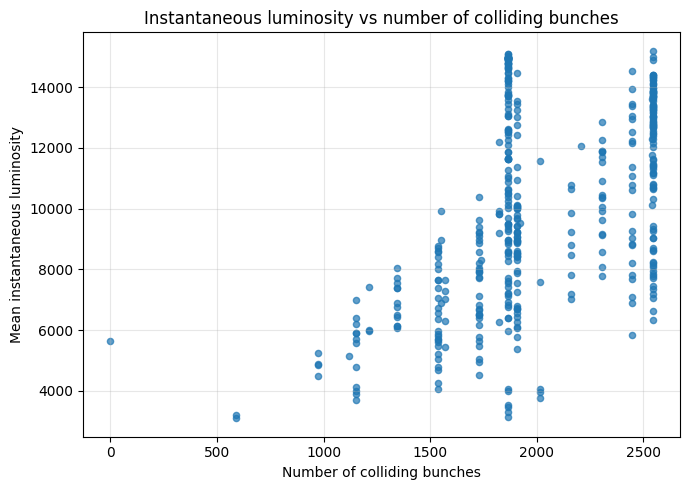

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(
    run_df["nBX"],
    run_df["mean_instLumi"],
    s=20,
    alpha=0.7
)

plt.xlabel("Number of colliding bunches")
plt.ylabel("Mean instantaneous luminosity")
plt.title("Instantaneous luminosity vs number of colliding bunches")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("instLumi_vs_nBX.png", dpi=200)
plt.show()

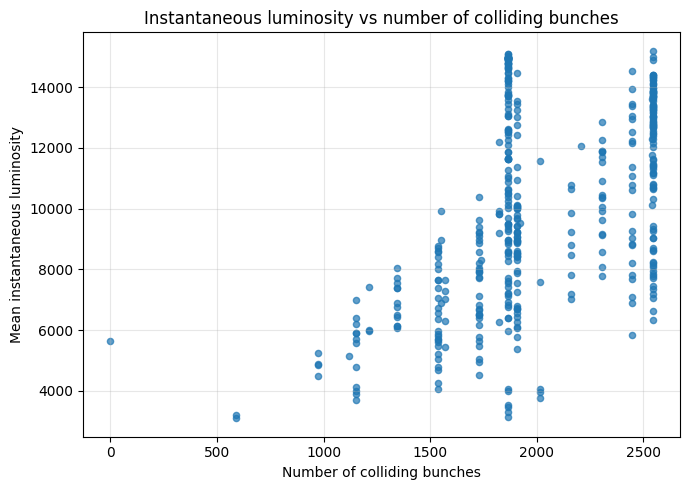

In [33]:
plt.figure(figsize=(7, 5))

plt.scatter(
    run_df["nBX"],
    run_df["mean_instLumi"],
    s=20,
    alpha=0.7
)

plt.xlabel("Number of colliding bunches")
plt.ylabel("Mean instantaneous luminosity")
plt.title("Instantaneous luminosity vs number of colliding bunches")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("instLumi_vs_nBX.png", dpi=200)
plt.show()

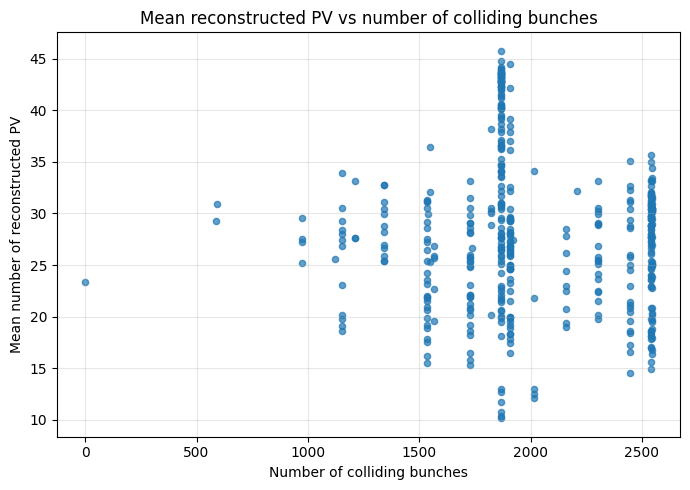

In [34]:
plt.figure(figsize=(7, 5))

plt.scatter(
    run_df["nBX"],
    run_df["mean_PV"],
    s=20,
    alpha=0.7
)

plt.xlabel("Number of colliding bunches")
plt.ylabel("Mean number of reconstructed PV")
plt.title("Mean reconstructed PV vs number of colliding bunches")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("meanPV_vs_nBX.png", dpi=200)
plt.show()

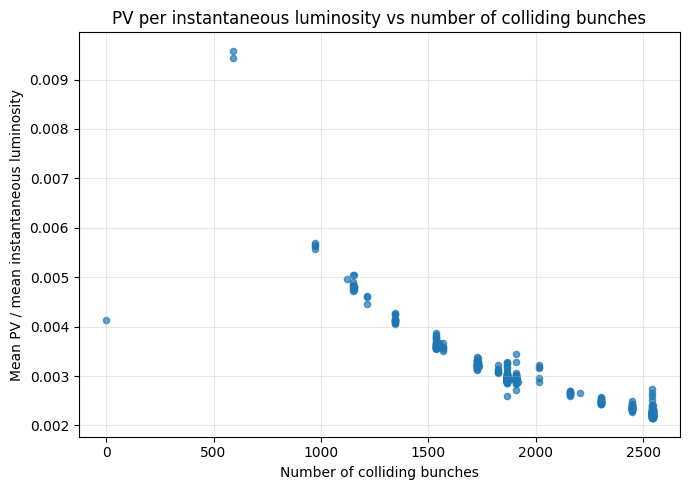

In [35]:
plt.figure(figsize=(7, 5))

plt.scatter(
    run_df["nBX"],
    run_df["PV_over_instLumi"],
    s=20,
    alpha=0.7
)

plt.xlabel("Number of colliding bunches")
plt.ylabel("Mean PV / mean instantaneous luminosity")
plt.title("PV per instantaneous luminosity vs number of colliding bunches")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("PV_over_instLumi_vs_nBX.png", dpi=200)
plt.show()

In [36]:
bx_min = 2100
bx_max = 2200

fixed_bx_df = plot_df[
    (plot_df["nBX"] >= bx_min) &
    (plot_df["nBX"] <= bx_max)
].copy()

print("Selected entries:", len(fixed_bx_df))
print(fixed_bx_df["nBX"].value_counts().sort_index())

Selected entries: 175851
nBX
2161.0    175851
Name: count, dtype: int64


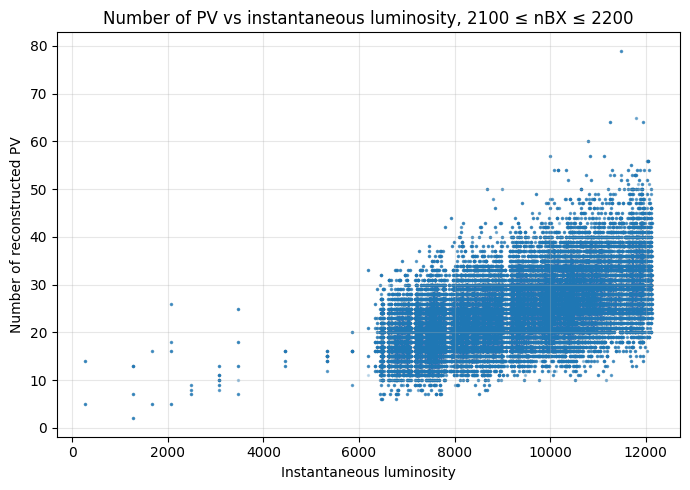

In [37]:
plt.figure(figsize=(7, 5))

plt.scatter(
    fixed_bx_df["_instlumi_dcsjson"],
    fixed_bx_df["_n_PV"],
    s=2,
    alpha=0.2
)

plt.xlabel("Instantaneous luminosity")
plt.ylabel("Number of reconstructed PV")
plt.title(f"Number of PV vs instantaneous luminosity, {bx_min} ≤ nBX ≤ {bx_max}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"nPV_vs_instLumi_nBX_{bx_min}_{bx_max}.png", dpi=200)
plt.show()

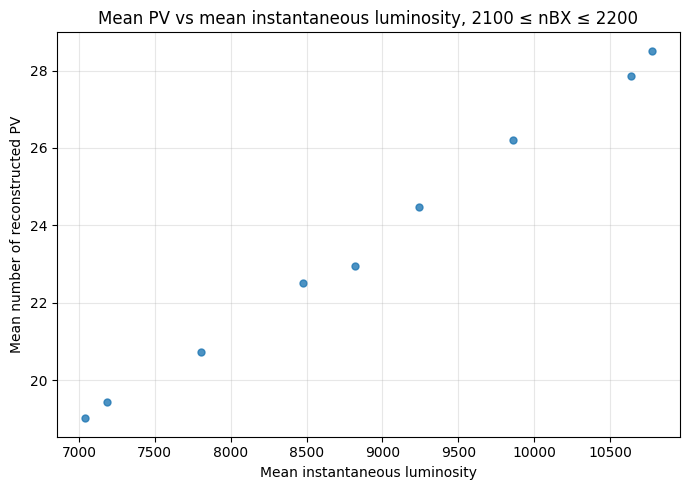

In [38]:
fixed_run_df = run_df[
    (run_df["nBX"] >= bx_min) &
    (run_df["nBX"] <= bx_max)
]

plt.figure(figsize=(7, 5))

plt.scatter(
    fixed_run_df["mean_instLumi"],
    fixed_run_df["mean_PV"],
    s=25,
    alpha=0.8
)

plt.xlabel("Mean instantaneous luminosity")
plt.ylabel("Mean number of reconstructed PV")
plt.title(f"Mean PV vs mean instantaneous luminosity, {bx_min} ≤ nBX ≤ {bx_max}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"meanPV_vs_meanInstLumi_nBX_{bx_min}_{bx_max}.png", dpi=200)
plt.show()